# Graded Layers

This notebook replaces the sharp `SiO2 / TiO2` interface with true intermediate mixed layers and compares the optical response against the original abrupt stack.

In [ ]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxlayerlumos import stackrt
from jaxlayerlumos import utils_graded_layers
from jaxlayerlumos import utils_layers
from jaxlayerlumos import utils_materials
from jaxlayerlumos import utils_spectra
from jaxlayerlumos import utils_units

Build an abrupt `Air / SiO2 / TiO2 / Air` stack. The zero-thickness air layers act as the surrounding media.

In [ ]:
num_wavelengths = 200
wavelengths = jnp.linspace(400e-9, 800e-9, num_wavelengths)
frequencies = utils_spectra.convert_wavelengths_to_frequencies(wavelengths)

materials = ["Air", "SiO2", "TiO2", "Air"]
n_k_abrupt = utils_materials.get_n_k(materials, frequencies)
thicknesses_abrupt = utils_layers.get_thicknesses_surrounded_by_air(
    jnp.array([120e-9, 160e-9])
)

n_k_abrupt.shape, thicknesses_abrupt

((200, 4), Array([0.0e+00, 1.2e-07, 1.6e-07, 0.0e+00], dtype=float64))

Insert 10 true graded layers at the positive-thickness internal interface. The pure `SiO2` and pure `TiO2` layers remain as endpoints, with half of the graded thickness deducted from each side.

In [ ]:
num_graded_layers = 10
grade_thickness = 40e-9

n_k_graded, thicknesses_graded = utils_graded_layers.get_graded_layers(
    n_k_abrupt,
    thicknesses_abrupt,
    num_graded_layers=num_graded_layers,
    grade_thickness=grade_thickness,
)

print("Abrupt layers:", n_k_abrupt.shape[1])
print("Graded layers:", n_k_graded.shape[1])
print("Total thickness before (nm):", utils_units.convert_m_to_nm(jnp.sum(thicknesses_abrupt)))
print("Total thickness after  (nm):", utils_units.convert_m_to_nm(jnp.sum(thicknesses_graded)))
print("Graded thicknesses (nm):", utils_units.convert_m_to_nm(thicknesses_graded))

Abrupt layers: 4
Graded layers: 14
Total thickness before (nm): 279.99999999999994
Total thickness after  (nm): 280.00000000000006
Graded thicknesses (nm): [  0. 100.   4.   4.   4.   4.   4.   4.   4.   4.   4.   4. 140.   0.]


The generated fractions start near material 1 and end near material 2; the pure endpoint materials are not counted as graded layers.

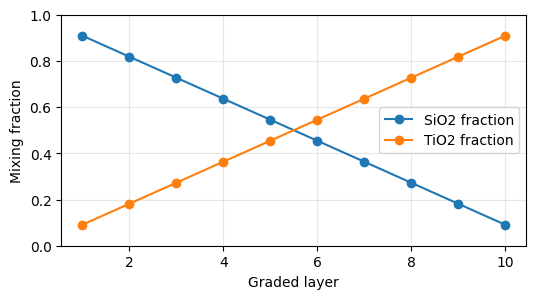

In [ ]:
material_2_fraction = utils_graded_layers.get_mixing_ratios(num_graded_layers)

fig, ax = plt.subplots(figsize=(6, 3))
layer_numbers = jnp.arange(1, num_graded_layers + 1)
ax.plot(layer_numbers, 1 - material_2_fraction, "o-", label="SiO2 fraction")
ax.plot(layer_numbers, material_2_fraction, "o-", label="TiO2 fraction")
ax.set_xlabel("Graded layer")
ax.set_ylabel("Mixing fraction")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

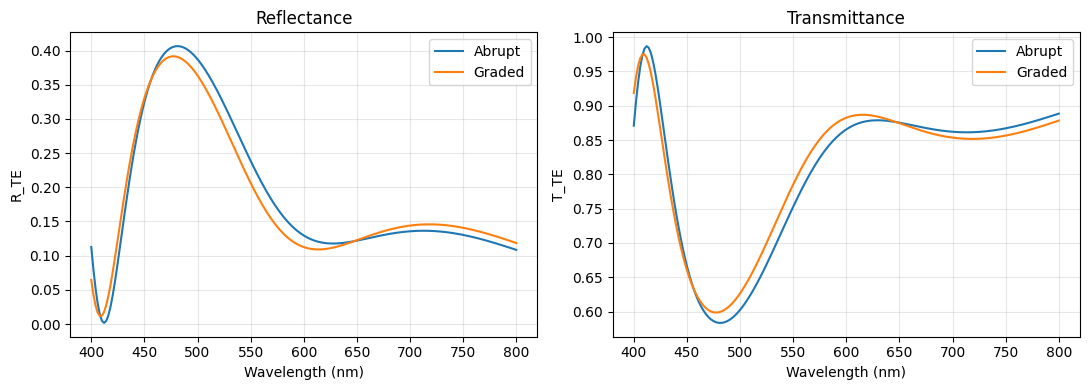

In [9]:
R_TE_abrupt, T_TE_abrupt, _, _ = stackrt(n_k_abrupt, thicknesses_abrupt, frequencies, 0.0)
R_TE_graded, T_TE_graded, _, _ = stackrt(n_k_graded, thicknesses_graded, frequencies, 0.0)

wavelengths_nm = utils_units.convert_m_to_nm(wavelengths)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
axes[0].plot(wavelengths_nm, R_TE_abrupt[0], label="Abrupt")
axes[0].plot(wavelengths_nm, R_TE_graded[0], label="Graded")
axes[0].set_title("Reflectance")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("R_TE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(wavelengths_nm, T_TE_abrupt[0], label="Abrupt")
axes[1].plot(wavelengths_nm, T_TE_graded[0], label="Graded")
axes[1].set_title("Transmittance")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("T_TE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()